<a href="https://colab.research.google.com/github/Santibareiro27/Inteligencia-Computacional/blob/main/RA1_LAB2/EXPERIENCIA_4%20/RA1_Lab_N%C2%B02_G8.ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laboratorio 2 — Aprendizaje en Redes Neuronales Artificiales


## Experiencia 4: Segmentación de grietas en estructuras de hormigón — UNet



**Dataset:** Imágenes de superficie de hormigón con máscaras binarias de grietas  
**Framework:** TensorFlow / Keras 3  
**Grupo:** — Axel Sk.  
**Fecha:** — 05/2026

---

> **Nota de lectura.** Este notebook introduce la segmentación semántica: no clasificar una imagen completa, sino etiquetar cada uno de sus píxeles. El problema de las grietas en hormigón es un caso canónico de segmentación de objetos finos — las grietas son estructuras elongadas, de ancho de 1 a pocos píxeles, que pueden aparecer en cualquier orientación, iluminación y textura de superficie.
>
> La arquitectura referencia es U-Net (Ronneberger et al., 2015), diseñada originalmente para imágenes biomédicas pero que se convirtió en el estándar para segmentación binaria con datasets pequeños. Su contribución central (las **skip connections**) será analizada empíricamente en este notebook.

---



## 0. Contexto del problema


  Una constructora necesita automatizar la detección de grietas en
  estructuras de hormigón. El proceso manual es lento, caro y subjetivo.
  El sistema debe:
  - Recibir una imagen de superficie de hormigón
  - Generar una máscara binaria que delimite las zonas agrietadas
  - Calcular el % de área afectada para estimar el daño

**DIFERENCIAS CON LA CLASIFICACIÓN CONVENCIONAL**:  
  - Clasificación: 1 etiqueta por imagen (grieta / sin grieta)
  - Segmentación:  1 etiqueta por PÍXEL (grieta / fondo)
  - Con imágenes de 256×256: 65.536 predicciones por imagen
  - La arquitectura debe capturar tanto contexto global (¿hay grieta?)
    como detalles locales (¿exactamente dónde está el borde?)

**RETO ESPECIAL DE LAS GRIETAS**:  
  - Estructuras muy delgadas: 1-3 píxeles de ancho
  - Alta relación de aspecto: largas y sinuosas
  - Desbalance extremo: típicamente 5-20% de píxeles son grieta
  - Variabilidad en: iluminación, textura del hormigón, tipo de grieta
  - Sin orientación preferencial: aparecen en cualquier ángulo


---



## 1. Configuración del entorno


In [ ]:
!wget -c --no-check-certificate "https://drive.google.com/uc?export=download&id=1MMQXhR3-Q0xSFskI7lC8mEhywkzTlhVc&confirm=t" -O concreto_agrietado_segmentacion.zip
# Descomprimir dataset
!unzip -qq concreto_agrietado_segmentacion.zip

--2026-05-20 21:14:13--  https://drive.google.com/uc?export=download&id=1MMQXhR3-Q0xSFskI7lC8mEhywkzTlhVc&confirm=t
Resolving drive.google.com (drive.google.com)... 74.125.202.100, 74.125.202.113, 74.125.202.101, ...
Connecting to drive.google.com (drive.google.com)|74.125.202.100|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1MMQXhR3-Q0xSFskI7lC8mEhywkzTlhVc&export=download [following]
--2026-05-20 21:14:13--  https://drive.usercontent.google.com/download?id=1MMQXhR3-Q0xSFskI7lC8mEhywkzTlhVc&export=download
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 74.125.132.132, 2607:f8b0:4001:c00::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|74.125.132.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4079099 (3.9M) [application/octet-stream]
Saving to: ‘concreto_agrietado_segmentacion.zip’

concreto_agrietado_ 100%[========

In [ ]:
# Verificar versiones para Keras 3
import tensorflow as tf
import keras
print(f"TensorFlow: {tf.__version__}")
print(f"Keras:      {keras.__version__}")
assert int(keras.__version__.split('.')[0]) >= 3, "Este notebook requiere Keras 3"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cv2
import os
import glob
import time
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from typing import Tuple, List, Optional

import keras
from keras import layers, ops
from keras.callbacks import (EarlyStopping, ReduceLROnPlateau,
                              ModelCheckpoint, LambdaCallback)

from sklearn.model_selection import train_test_split
from sklearn.metrics import (jaccard_score, f1_score,
                              confusion_matrix, ConfusionMatrixDisplay)

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Parámetros globales del pipeline de imágenes
IMG_SIZE   = 256       # resolución de trabajo (múltiplo de 2^depth)
N_CHANNELS = 1         # Grayscale — justificado en Sección 3
BATCH_SIZE = 8         # ajustar según RAM disponible
MASK_THR   = 0.5       # umbral para binarizar predicciones

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False,
                     "axes.spines.right": False, "figure.facecolor": "white"})

print("Entorno configurado. Keras 3 detectado.")

TensorFlow: 2.20.0
Keras:      3.13.2
Entorno configurado. Keras 3 detectado.



---



## 2. Carga y estructura del dataset


Imágenes encontradas: 410
Máscaras: 410


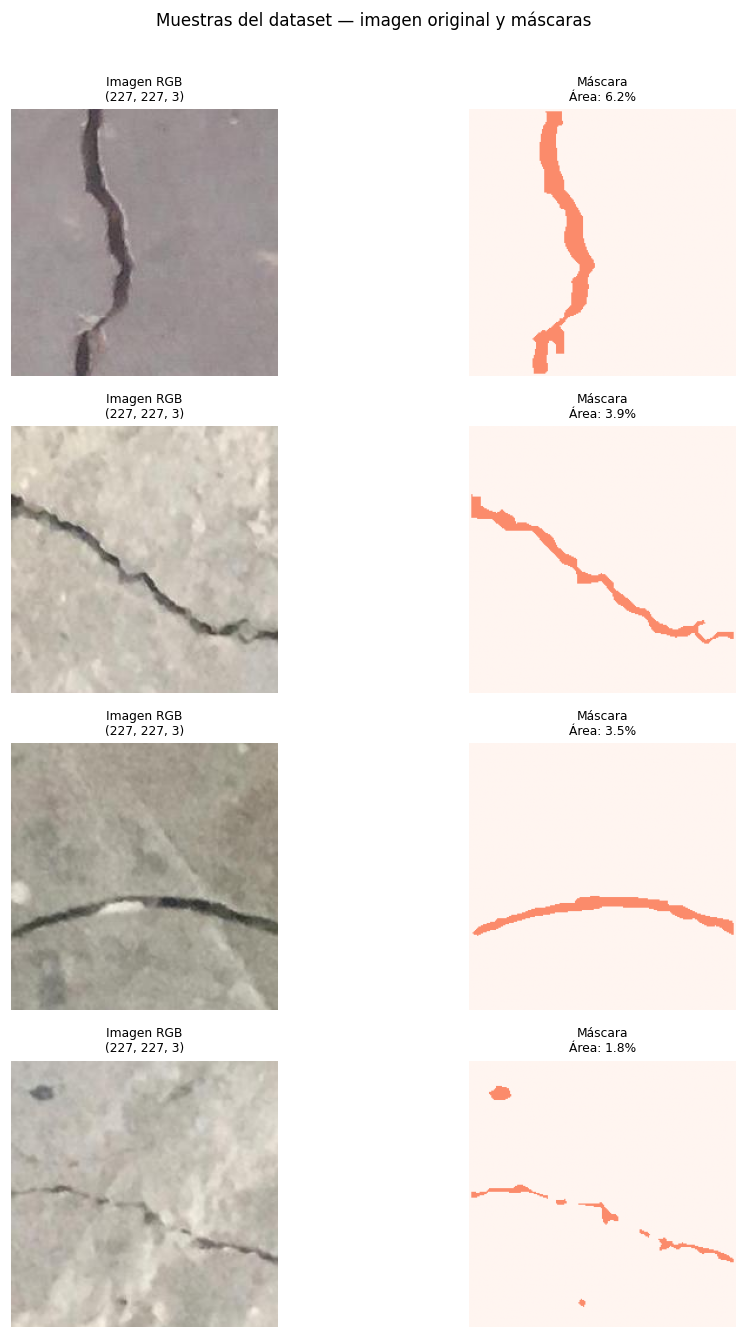

In [ ]:
# ═══════════════════════════════════════════════════════════════
# ESTRUCTURA ESPERADA DEL DATASET
# ═══════════════════════════════════════════════════════════════
# dataset/
#   cracks/          ← imágenes RGB originales
#   labels/          ← máscaras
#
# Cada imagen tiene su máscara con el mismo nombre de archivo.
# Máscaras: píxel color (101) = grieta, negro (0) = fondo
# ═══════════════════════════════════════════════════════════════

DATA_ROOT  = Path("/content/")
IMG_DIR    = DATA_ROOT / "cracks"
MASK_DIR = DATA_ROOT / "labels"

# Verificar estructura
for d in [IMG_DIR, MASK_DIR]:
    if not d.exists():
        print(f"  AVISO: {d} no encontrado — usar ruta correcta del dataset")

# Listar imágenes disponibles
img_paths = sorted(glob.glob(str(IMG_DIR / "*.jpg")) +
                   glob.glob(str(IMG_DIR / "*.png")))

print(f"Imágenes encontradas: {len(img_paths)}")

# Verificar que existan las máscaras
n_masks_a = len(glob.glob(str(MASK_DIR / "*")))
print(f"Máscaras: {n_masks_a}")


# Mostrar ejemplos
n_show = min(4, len(img_paths))
if n_show > 0:
    fig, axes = plt.subplots(n_show, 2, figsize=(10, 3*n_show))
    if n_show == 1:
        axes = axes.reshape(1, -1)

    for i, img_path in enumerate(img_paths[:n_show]):
        stem = Path(img_path).stem
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Máscaras
        mask_path = MASK_DIR / (stem + ".png")
        mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE) if mask_path.exists() else np.zeros((256,256))

        axes[i, 0].imshow(img)
        axes[i, 0].set_title(f"Imagen RGB\n{img.shape}", fontsize=8)
        axes[i, 1].imshow(mask, cmap='Reds', vmin=0, vmax=255)
        axes[i, 1].set_title(f"Máscara\nÁrea: {(mask>100).mean()*100:.1f}%", fontsize=8)
        for ax in axes[i]: ax.axis('off')

    plt.suptitle("Muestras del dataset — imagen original y máscaras",
                 fontsize=11, y=1.01)
    plt.tight_layout()
    plt.show()


---



## 3. Preprocesamiento de imágenes


### 3.1 ¿Por qué convertir a escala de grises?


**ANÁLISIS: ¿APORTA EL COLOR INFORMACIÓN PARA DETECTAR GRIETAS?**

Las grietas en hormigón se definen por:  
  - Contraste de intensidad (borde grieta vs. superficie)
  - Textura local (grieta vs. granulado del hormigón)
  - Morfología (estructura lineal o ramificada)

El color NO define una grieta. Una grieta en hormigón:  
  - No tiene un color específico (puede ser oscura, blanca, gris)
  - El mismo tipo de grieta puede tener apariencias muy distintas
    según la iluminación, la humedad o la edad del hormigón

**CONSECUENCIAS PRÁCTICAS DE USAR GRAYSCALE:**

  1. Reducción de canales: 3 → 1
     - Entrada: 256×256×3 = 196.608 valores → 256×256×1 = 65.536 valores
     - La primera capa del encoder procesa 3× menos datos
     - Los filtros de la primera convolución pasan de 3×3×3=27 a 3×3×1=9 pesos
     → Aprende más rápido, con menos datos, sin perder información relevante

  2. Aumento de datos más efectivo:
     - Jitter de color es irrelevante → no aplica
     - El modelo no puede usar color como atajo → aprende geometría real

  3. Invarianza a condición de iluminación:
     - Las cámaras de campo pueden tener balance de blancos distinto
     - La normalización de luminancia es suficiente en grayscale

Varianza por canal en la imagen de ejemplo:
  Canal R: 250.4
  Canal G: 261.9
  Canal B: 247.3
  Grayscale:  255.8

Si la varianza del grayscale es similar a la de los canales RGB,
el color no añade información estructural significativa.


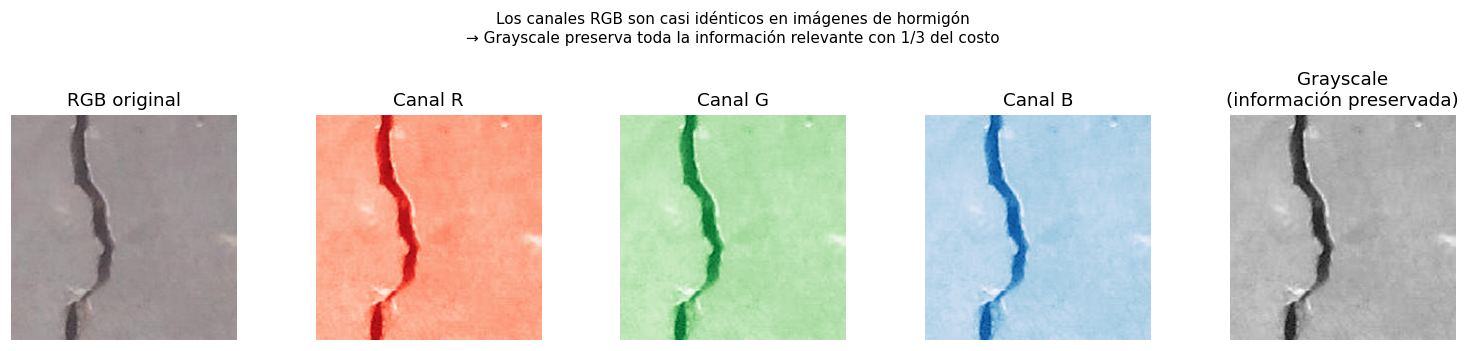

In [ ]:
# Demostración visual: RGB vs Grayscale para grietas
if len(img_paths) > 0:
    img_demo = cv2.imread(img_paths[0])
    img_rgb  = cv2.cvtColor(img_demo, cv2.COLOR_BGR2RGB)
    img_gray = cv2.cvtColor(img_demo, cv2.COLOR_BGR2GRAY)

    # Análisis de varianza por canal
    print("Varianza por canal en la imagen de ejemplo:")
    for i, name in enumerate(['R', 'G', 'B']):
        print(f"  Canal {name}: {img_rgb[:,:,i].var():.1f}")
    print(f"  Grayscale:  {img_gray.var():.1f}")
    print()
    print("Si la varianza del grayscale es similar a la de los canales RGB,")
    print("el color no añade información estructural significativa.")

    fig, axes = plt.subplots(1, 5, figsize=(14, 3))
    axes[0].imshow(img_rgb); axes[0].set_title("RGB original")
    axes[1].imshow(img_rgb[:,:,0], cmap='Reds_r');   axes[1].set_title("Canal R")
    axes[2].imshow(img_rgb[:,:,1], cmap='Greens_r');  axes[2].set_title("Canal G")
    axes[3].imshow(img_rgb[:,:,2], cmap='Blues_r');   axes[3].set_title("Canal B")
    axes[4].imshow(img_gray, cmap='gray');            axes[4].set_title("Grayscale\n(información preservada)")
    for ax in axes: ax.axis('off')
    plt.suptitle("Los canales RGB son casi idénticos en imágenes de hormigón\n"
                 "→ Grayscale preserva toda la información relevante con 1/3 del costo",
                 fontsize=10, y=1.05)
    plt.tight_layout()
    plt.show()

### 3.2 Pipeline de carga y normalización


In [ ]:
def cargar_imagen(path: str, size: int = IMG_SIZE,
                   grayscale: bool = True) -> np.ndarray:
    """
    Carga y preprocesa una imagen para el pipeline de segmentación.

    Pasos:
    1. Leer con OpenCV
    2. Convertir a grayscale (si se solicita)
    3. Redimensionar a size × size
    4. Normalizar a [0, 1]
    5. Expandir dimensión de canal → shape (size, size, 1)
    """
    img = cv2.imread(path)
    if img is None:
        raise ValueError(f"No se pudo leer: {path}")

    if grayscale:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    else:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    img = cv2.resize(img, (size, size), interpolation=cv2.INTER_AREA)
    img = img.astype(np.float32) / 255.0

    if grayscale:
        img = np.expand_dims(img, axis=-1)   # (H, W) → (H, W, 1)
    return img


def cargar_mascara(path: str, size: int = IMG_SIZE) -> np.ndarray:
    """
    Carga y preprocesa una máscara binaria de segmentación.

    Importante:
    · Siempre grayscale (la máscara es binaria por definición)
    · Binarizar: umbral 100 → {0, 1} float32
    · Shape: (H, W, 1) para compatibilidad con el modelo
    """
    mask = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if mask is None:
        # Máscara vacía si no existe (imagen sin grietas)
        mask = np.zeros((size, size), dtype=np.uint8)

    mask = cv2.resize(mask, (size, size), interpolation=cv2.INTER_NEAREST)
    # INTER_NEAREST para máscaras: no interpolar valores intermedios
    # INTER_AREA o INTER_LINEAR para imágenes: suavizado correcto

    mask = (mask > 100).astype(np.float32)   # binarizar: {0.0, 1.0}
    mask = np.expand_dims(mask, axis=-1)     # (H, W) → (H, W, 1)
    return mask


# Función de estadísticas del dataset
def estadisticas_dataset(img_paths, mask_dir, n_sample=None):
    """Calcula estadísticas de desbalance y tamaños originales."""
    paths = img_paths[:n_sample] if n_sample else img_paths
    tamaños, crack_fracs = [], []

    for p in paths:
        stem = Path(p).stem
        img  = cv2.imread(p)
        tamaños.append(img.shape[:2] if img is not None else (0, 0))
        mp = Path(mask_dir) / (stem + ".png")
        if mp.exists():
            m = cv2.imread(str(mp), cv2.IMREAD_GRAYSCALE)
            crack_fracs.append((m > 100).mean() if m is not None else 0)

    tamaños_arr   = np.array(tamaños)
    crack_arr     = np.array(crack_fracs)

    print(f"  Tamaños originales: H=[{tamaños_arr[:,0].min()}-{tamaños_arr[:,0].max()}]  "
          f"W=[{tamaños_arr[:,1].min()}-{tamaños_arr[:,1].max()}]")
    print(f"  Fracción de grieta: media={crack_arr.mean()*100:.1f}%  "
          f"P10={np.percentile(crack_arr,10)*100:.1f}%  "
          f"P90={np.percentile(crack_arr,90)*100:.1f}%")
    print(f"  Imágenes sin grieta: {(crack_arr < 0.001).sum()}/{len(crack_arr)}")
    return crack_arr


if len(img_paths) > 0:
    print("Estadísticas del dataset:")
    crack_fracs_a = estadisticas_dataset(img_paths, MASK_DIR, n_sample=200)

Estadísticas del dataset:
  Tamaños originales: H=[227-227]  W=[227-227]
  Fracción de grieta: media=10.4%  P10=4.1%  P90=16.9%
  Imágenes sin grieta: 0/200


### 3.3 Redimensionamiento y por qué importa `IMG_SIZE = 256`


**¿POR QUÉ 256×256?**

La U-Net estándar con profundidad 4 hace 4 maxpooling de 2×2:
  256 → 128 → 64 → 32 → 16  (en el cuello de botella)

El tamaño debe ser divisible por `2^depth` para que las dimensiones
se alineen perfectamente al hacer upsampling en el decoder.
Si no, las skip connections no encajan → error de forma o necesidad de crop.

-  depth=3 → mínimo 8, múltiplos de 8:   64, 128, 256
-  depth=4 → mínimo 16, múltiplos de 16: 64, 128, 256, 512
-  depth=5 → mínimo 32, múltiplos de 32: 128, 256, 512

Con las imágenes de grietas (originalmente `~227×227` o variables):  
  - 256×256 es el estándar más usado en la literatura
  - Pequeño detalle: al redimensionar, las grietas muy delgadas pueden
    perderse si la imagen original es mucho más grande que 256×256
  - Solución: patchify (dividir en parches solapados) para imágenes grandes

**INTERPOLACIÓN CORRECTA** (*esto se aprende bien en procesamiento digital de imágenes, por si deciden esa optativa*):  
 - `cv2.INTER_AREA`   → para reducir imágenes (downsampling): promedia píxeles
 - `cv2.INTER_LINEAR` → para agrandar imágenes (upsampling): interpolación bilineal
 - `cv2.INTER_NEAREST` → para máscaras SIEMPRE: no crear valores intermedios
    (si interpolamos linealmente una máscara binaria, aparece gris entre 0 y 1)

### 3.4 Construcción del dataset con `tf.data`


In [ ]:
def construir_dataset(img_paths: List[str], mask_dir: str,
                       size: int = IMG_SIZE, batch_size: int = BATCH_SIZE,
                       shuffle: bool = True, augment: bool = False,
                       seed: int = SEED) -> tf.data.Dataset:
    """
    Construye un pipeline tf.data para carga eficiente.

    Ventajas vs. cargar todo en RAM:
    · Solo carga el batch actual → datasets grandes sin OOM
    · Prefetch: carga el siguiente batch mientras entrena el actual
    · Shuffle dinámico: mezcla en cada época (sin cargar todo)
    """
    img_list  = tf.constant(img_paths)
    stem_list = [Path(p).stem for p in img_paths]
    mask_list = tf.constant([str(Path(mask_dir) / (s + ".png"))
                              for s in stem_list])

    def _load_pair(img_path, mask_path):
        # Cargar imagen
        img = tf.io.read_file(img_path)
        img = tf.image.decode_png(img, channels=3)
        img = tf.image.rgb_to_grayscale(img)            # RGB → Grayscale
        img = tf.image.resize(img, [size, size],
                               method='area')           # INTER_AREA equiv.
        img = tf.cast(img, tf.float32) / 255.0

        # Cargar máscara
        mask_raw = tf.io.read_file(mask_path)
        mask = tf.image.decode_png(mask_raw, channels=1)
        mask = tf.image.resize(mask, [size, size],
                                method='nearest')       # INTER_NEAREST equiv.
        mask = tf.cast(mask > 100, tf.float32)
        return img, mask

    def _augment(img, mask):
        """
        Augmentación aplicada SIMULTÁNEAMENTE a imagen y máscara.
        Clave: usar la misma semilla para ambas → la transformación es coherente.
        """
        seed_op = tf.random.experimental.stateless_split(
            tf.constant([seed, seed], dtype=tf.int32), num=8)

        # Flip horizontal
        if tf.random.uniform(()) > 0.5:
            img  = tf.image.flip_left_right(img)
            mask = tf.image.flip_left_right(mask)

        # Flip vertical
        if tf.random.uniform(()) > 0.5:
            img  = tf.image.flip_up_down(img)
            mask = tf.image.flip_up_down(mask)

        # Rotación 90° múltiplos
        k = tf.random.uniform((), 0, 4, dtype=tf.int32)
        img  = tf.image.rot90(img,  k=k)
        mask = tf.image.rot90(mask, k=k)

        # Brillo y contraste SOLO en imagen, no en máscara
        img = tf.image.random_brightness(img, max_delta=0.15)
        img = tf.image.random_contrast(img, lower=0.8, upper=1.2)
        img = tf.clip_by_value(img, 0.0, 1.0)

        return img, mask

    ds = tf.data.Dataset.from_tensor_slices((img_list, mask_list))

    if shuffle:
        ds = ds.shuffle(buffer_size=len(img_paths), seed=seed)

    ds = ds.map(_load_pair, num_parallel_calls=tf.data.AUTOTUNE)

    if augment:
        ds = ds.map(_augment, num_parallel_calls=tf.data.AUTOTUNE)

    ds = ds.batch(batch_size)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds


# División del dataset
if len(img_paths) > 0:
    idx_all = list(range(len(img_paths)))
    idx_train, idx_test = train_test_split(idx_all, test_size=0.15,
                                            random_state=SEED)
    idx_train, idx_val  = train_test_split(idx_train, test_size=0.15,
                                            random_state=SEED)

    train_paths = [img_paths[i] for i in idx_train]
    val_paths   = [img_paths[i] for i in idx_val]
    test_paths  = [img_paths[i] for i in idx_test]

    ds_train = construir_dataset(train_paths, str(MASK_DIR),
                                  augment=True, shuffle=True)
    ds_val   = construir_dataset(val_paths,   str(MASK_DIR),
                                  augment=False, shuffle=False)
    ds_test  = construir_dataset(test_paths,  str(MASK_DIR),
                                  augment=False, shuffle=False)

    print(f"Train: {len(train_paths)} imágenes  "
          f"Val: {len(val_paths)}  Test: {len(test_paths)}")
    print(f"Batches por época: {len(ds_train)}")
else:
    print("Sin imágenes cargadas — verificar rutas del dataset.")

Train: 295 imágenes  Val: 53  Test: 62
Batches por época: 37



---



## 5. Métricas de segmentación


**¿POR QUÉ EL ACCURACY DE PÍXELES NO ES SUFICIENTE?**  

Con 5-15% de píxeles de grieta, un modelo que predice "todo fondo"
obtiene 85-95% de accuracy de píxeles (sin detectar ninguna grieta).

MÉTRICAS CORRECTAS PARA SEGMENTACIÓN BINARIA:  

 - IoU (*Intersection over Union*) = Jaccard Index:  
    IoU = TP / (TP + FP + FN)
    - Penaliza tanto FP como FN por igual
    - Estándar en segmentación semántica
    - IoU = 0: sin predicciones correctas
    - IoU = 1: predicción perfecta
    - IoU < 0.5: generalmente inaceptable para producción

 - Dice Coefficient = F1-score a nivel de píxel:  
    Dice = 2TP / (2TP + FP + FN) = 2IoU / (1 + IoU)
    - Más sensible a pequeñas regiones que IoU
    - Dice es siempre >= IoU

 - Binary Cross-Entropy (loss durante entrenamiento):  
    - Trata cada píxel independientemente
    - Ignora el desbalance → el modelo puede ignorar la clase grieta

 - Dice Loss (loss alternativo):  
    DiceLoss = 1 - Dice
    - Optimiza directamente la métrica de evaluación
    - Robusto al desbalance de clases → recomendado para grietas

 - Focal Loss:  
    FocalLoss = -α(1-p)^γ log(p)
    - Penaliza más los ejemplos difíciles
    - Útil cuando muchos píxeles son "fáciles de clasificar"

In [ ]:
# Implementación de métricas en Keras
class DiceCoefficient(keras.metrics.Metric):
    """Dice Coefficient como métrica de Keras (monitoreable en callbacks)."""
    def __init__(self, threshold=0.5, smooth=1e-6, name='dice', **kwargs):
        super().__init__(name=name, **kwargs)
        self.threshold = threshold
        self.smooth    = smooth
        self.dice_sum  = self.add_weight(name='dice_sum', initializer='zeros')
        self.count     = self.add_weight(name='count',    initializer='zeros')

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_pred_bin = tf.cast(y_pred > self.threshold, tf.float32)
        y_true     = tf.cast(y_true, tf.float32)
        intersection = tf.reduce_sum(y_true * y_pred_bin, axis=[1, 2, 3])
        denom        = tf.reduce_sum(y_true + y_pred_bin,  axis=[1, 2, 3])
        dice         = tf.reduce_mean((2 * intersection + self.smooth) /
                                       (denom + self.smooth))
        self.dice_sum.assign_add(dice)
        self.count.assign_add(1.0)

    def result(self):
        return self.dice_sum / (self.count + 1e-10)

    def reset_state(self):
        self.dice_sum.assign(0.0)
        self.count.assign(0.0)


class IoUMetric(keras.metrics.Metric):
    """IoU (Jaccard) como métrica de Keras."""
    def __init__(self, threshold=0.5, smooth=1e-6, name='iou', **kwargs):
        super().__init__(name=name, **kwargs)
        self.threshold = threshold
        self.smooth    = smooth
        self.iou_sum   = self.add_weight(name='iou_sum', initializer='zeros')
        self.count     = self.add_weight(name='count',   initializer='zeros')

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_pred_bin   = tf.cast(y_pred > self.threshold, tf.float32)
        y_true       = tf.cast(y_true, tf.float32)
        intersection = tf.reduce_sum(y_true * y_pred_bin, axis=[1, 2, 3])
        union        = tf.reduce_sum(y_true + y_pred_bin, axis=[1, 2, 3]) - intersection
        iou          = tf.reduce_mean((intersection + self.smooth) /
                                       (union + self.smooth))
        self.iou_sum.assign_add(iou)
        self.count.assign_add(1.0)

    def result(self):
        return self.iou_sum / (self.count + 1e-10)

    def reset_state(self):
        self.iou_sum.assign(0.0)
        self.count.assign(0.0)


# Funciones de pérdida
def dice_loss(y_true, y_pred, smooth=1e-6):
    """Dice Loss: 1 - Dice Coefficient. Directamente optimiza la métrica."""
    y_true = tf.cast(y_true, tf.float32)
    intersection = tf.reduce_sum(y_true * y_pred, axis=[1, 2, 3])
    denom        = tf.reduce_sum(y_true + y_pred,  axis=[1, 2, 3])
    dice         = (2 * intersection + smooth) / (denom + smooth)
    return 1.0 - tf.reduce_mean(dice)


def bce_dice_loss(y_true, y_pred):
    """
    Combinación de Binary Cross-Entropy y Dice Loss.
    BCE: convergencia rápida al inicio (gradientes claros).
    Dice: mejor optimización para clases desbalanceadas.
    El balance 0.5/0.5 es el más común en la literatura.
    """
    bce  = keras.losses.binary_crossentropy(y_true, y_pred)
    bce  = tf.reduce_mean(bce)
    dl   = dice_loss(y_true, y_pred)
    return 0.5 * bce + 0.5 * dl


def focal_loss(y_true, y_pred, gamma=2.0, alpha=0.25):
    """
    Focal Loss para segmentación con grietas muy delgadas.
    γ (gamma): penalización de ejemplos fáciles (típico: 2.0)
    α (alpha): balanceo de clases (típico: 0.25 para clase grieta)
    """
    y_true   = tf.cast(y_true, tf.float32)
    y_pred   = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
    bce      = -y_true * tf.math.log(y_pred) - (1 - y_true) * tf.math.log(1 - y_pred)
    p_t      = y_true * y_pred + (1 - y_true) * (1 - y_pred)
    focal_w  = tf.pow(1 - p_t, gamma)
    alpha_w  = y_true * alpha + (1 - y_true) * (1 - alpha)
    return tf.reduce_mean(focal_w * alpha_w * bce)


print("Métricas y funciones de pérdida definidas:")
print("  · DiceCoefficient — métrica de evaluación")
print("  · IoUMetric       — métrica de evaluación")
print("  · dice_loss       — pérdida para entrenamiento")
print("  · bce_dice_loss   — pérdida combinada (recomendada)")
print("  · focal_loss      — pérdida para grietas muy delgadas")


Métricas y funciones de pérdida definidas:
  · DiceCoefficient — métrica de evaluación
  · IoUMetric       — métrica de evaluación
  · dice_loss       — pérdida para entrenamiento
  · bce_dice_loss   — pérdida combinada (recomendada)
  · focal_loss      — pérdida para grietas muy delgadas



---



## 6. Arquitectura U-Net parametrizada


**U-NET — Principios de diseño**

Propuesta por Ronneberger et al. (2015) para segmentación de imágenes
biomédicas con datasets pequeños.

CONTRIBUCIÓN CENTRAL: las skip connections (conexiones de salto)  
- El encoder comprime espacialmente la información (downsampling)
  → captura contexto pero pierde ubicación precisa
- Las skip connections conectan directamente el encoder al decoder
  del mismo nivel espacial
- El decoder puede reconstruir bordes precisos porque recibe
  tanto la representación comprimida (contexto) como la original
  (localización exacta)

SIN skip connections:  
 - Encoder: 256→128→64→32→16 (cuello de botella)
 - Decoder: 16→32→64→128→256
 - Problema: el modelo "sabe" que hay una grieta, pero no exactamente dónde

CON skip connections (U-Net):  
  Decoder en nivel 128 recibe:  
   - Upsampling(16) = 32D  [de la profundidad]  
   - Encoder nivel 128 =   [exactamente cómo era antes del pooling]
    → Puede reconstruir el borde exacto de la grieta

PARÁMETRO CLAVE: filters_base  
  Determina el número de filtros en la primera capa y escala
  exponencialmente con la profundidad:
   - `filters_base=16`: [16, 32, 64, 128] → `~0.5M` params
   - `filters_base=32`: [32, 64, 128, 256] → `~2M` params
   - `filters_base=64`: [64, 128, 256, 512] → `~8M` params

In [ ]:
def bloque_conv(x, filters: int, kernel_size: int = 3,
                 use_bn: bool = True, dropout: float = 0.0,
                 n_convs: int = 2, name_prefix: str = ""):
    """
    Bloque convolucional de U-Net: N × (Conv2D → BN → ReLU).

    Parámetros
    ----------
    x          : tensor de entrada
    filters    : número de filtros
    use_bn     : usar Batch Normalization
    dropout    : tasa de Dropout espacial (entre bloques)
    n_convs    : número de convoluciones en el bloque (típico: 2)
    name_prefix: prefijo para los nombres de capas

    Nota sobre padding='same':
    La salida tiene las mismas dimensiones espaciales que la entrada.
    Sin esto, la U-Net necesitaría recortes manuales en las skip connections.
    """
    for i in range(n_convs):
        x = layers.Conv2D(
            filters, kernel_size,
            padding='same',
            kernel_initializer='he_normal',
            use_bias=not use_bn,  # si BN: el bias es redundante
            name=f"{name_prefix}_conv{i}"
        )(x)
        if use_bn:
            x = layers.BatchNormalization(name=f"{name_prefix}_bn{i}")(x)
        x = layers.Activation('relu', name=f"{name_prefix}_relu{i}")(x)

    if dropout > 0:
        x = layers.SpatialDropout2D(dropout, name=f"{name_prefix}_drop")(x)
        # SpatialDropout2D: elimina canales completos (más efectivo que Dropout
        # estándar para feature maps espaciales — mantiene coherencia espacial)
    return x


def unet(input_shape: Tuple = (IMG_SIZE, IMG_SIZE, N_CHANNELS),
          filters_base: int = 32,
          depth: int = 4,
          use_bn: bool = True,
          dropout: float = 0.1,
          use_skip: bool = True,
          n_convs_per_block: int = 2,
          final_activation: str = 'sigmoid',
          nombre: str = 'unet') -> keras.Model:
    """
    U-Net parametrizada para segmentación binaria.

    Parámetros
    ----------
    input_shape      : (H, W, C) — imagen de entrada
    filters_base     : filtros en el primer nivel (escala × 2 en cada nivel)
    depth            : profundidad del encoder (número de downsampling steps)
    use_bn           : usar BatchNormalization en los bloques conv
    dropout          : tasa de SpatialDropout2D (0 = sin dropout)
    use_skip         : usar skip connections (False → Encoder-Decoder puro sin saltos)
    n_convs_per_block: convoluciones por bloque (2 = U-Net clásico)
    final_activation : 'sigmoid' para segmentación binaria
    nombre           : nombre del modelo Keras

    Arquitectura para filters_base=32, depth=4:
      Encoder: [32→64→128→256] + maxpooling
      Bottleneck: [512]
      Decoder: [256→128→64→32] + upsampling + skip
      Output: Conv2D(1, sigmoid)
    """
    inputs = keras.Input(shape=input_shape, name='input')
    x      = inputs

    # ─── ENCODER ────────────────────────────────────────────────
    skip_connections = []
    for d in range(depth):
        f    = filters_base * (2 ** d)
        x    = bloque_conv(x, f, use_bn=use_bn, dropout=dropout,
                            n_convs=n_convs_per_block, name_prefix=f'enc{d}')
        skip_connections.append(x)                        # guardar para skip
        x = layers.MaxPooling2D(2, name=f'pool{d}')(x)    # reducir 2×

    # ─── BOTTLENECK ─────────────────────────────────────────────
    f_bn = filters_base * (2 ** depth)
    x    = bloque_conv(x, f_bn, use_bn=use_bn, dropout=dropout * 1.5,
                        n_convs=n_convs_per_block, name_prefix='bottleneck')

    # ─── DECODER ────────────────────────────────────────────────
    for d in reversed(range(depth)):
        f = filters_base * (2 ** d)
        # Upsampling bilinear (alternativa: Conv2DTranspose)
        x = layers.UpSampling2D(size=2, interpolation='bilinear',
                                  name=f'up{d}')(x)
        x = layers.Conv2D(f, 2, padding='same', kernel_initializer='he_normal',
                           name=f'up_conv{d}')(x)

        # Skip connection: concatenar con la activación del encoder
        if use_skip:
            x = layers.Concatenate(name=f'concat{d}')([skip_connections[d], x])

        x = bloque_conv(x, f, use_bn=use_bn, dropout=dropout,
                         n_convs=n_convs_per_block, name_prefix=f'dec{d}')

    # ─── SALIDA ─────────────────────────────────────────────────
    # 1×1 conv: combinar los feature maps en 1 canal de segmentación
    outputs = layers.Conv2D(1, 1, activation=final_activation,
                              name='output')(x)

    return keras.Model(inputs, outputs, name=nombre)


# Demostración: construir y resumir el modelo por defecto
modelo_demo = unet(filters_base=32, depth=4)
modelo_demo.summary()

print(f"\nInput:  {modelo_demo.input_shape}")
print(f"Output: {modelo_demo.output_shape}")
print("Input y output tienen las mismas dimensiones espaciales → "
      "cada píxel de entrada tiene un píxel de salida.")


Model: "unet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 256, 256,  │          0 │ -                 │
│                     │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc0_conv0 (Conv2D) │ (None, 256, 256,  │        288 │ input[0][0]       │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc0_bn0            │ (None, 256, 256,  │        128 │ enc0_conv0[0][0]  │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc0_relu0          │ (None, 256, 256,  │          0 │ enc0_bn0[0][0]    │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc0_conv1 (Conv2D) │ (None, 256, 256,  │      9,216 │ enc0_relu0[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc0_bn1            │ (None, 256, 256,  │        128 │ enc0_conv1[0][0]  │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc0_relu1          │ (None, 256, 256,  │          0 │ enc0_bn1[0][0]    │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc0_drop           │ (None, 256, 256,  │          0 │ enc0_relu1[0][0]  │
│ (SpatialDropout2D)  │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool0               │ (None, 128, 128,  │          0 │ enc0_drop[0][0]   │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_conv0 (Conv2D) │ (None, 128, 128,  │     18,432 │ pool0[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_bn0            │ (None, 128, 128,  │        256 │ enc1_conv0[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_relu0          │ (None, 128, 128,  │          0 │ enc1_bn0[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_conv1 (Conv2D) │ (None, 128, 128,  │     36,864 │ enc1_relu0[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_bn1            │ (None, 128, 128,  │        256 │ enc1_conv1[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_relu1          │ (None, 128, 128,  │          0 │ enc1_bn1[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_drop           │ (None, 128, 128,  │          0 │ enc1_relu1[0][0]  │
│ (SpatialDropout2D)  │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 64, 64,    │          0 │ enc1_drop[0][0] 

 Total params: 7,768,353 (29.63 MB)

 Trainable params: 7,762,465 (29.61 MB)

 Non-trainable params: 5,888 (23.00 KB)


Input:  (None, 256, 256, 1)
Output: (None, 256, 256, 1)
Input y output tienen las mismas dimensiones espaciales → cada píxel de entrada tiene un píxel de salida.



---



## 7. Experimento: Skip Connections — ¿cuánto aportan?


**EXPERIMENTO CRÍTICO: ¿son necesarias las skip connections?**

Hipótesis: sin skip connections, el decoder no puede reconstruir
la ubicación exacta de grietas delgadas porque esa información
se pierde durante el downsampling del encoder.

Variantes a comparar:
  1. U-Net completa (con skip connections)
  2. Encoder-Decoder sin skip connections (arquitectura "plana")

La diferencia esperada es más pronunciada con:  
  - Estructuras finas (grietas de 1-2 píxeles)
  - Mayor profundidad del encoder
  - Menor tamaño del cuello de botella

In [ ]:
# Construir las dos variantes
modelo_unet_full = unet(filters_base=32, depth=4, use_skip=True,
                          nombre='unet_full')
modelo_unet_nosup = unet(filters_base=32, depth=4, use_skip=False,
                           nombre='unet_no_skip')

print(f"U-Net con skip connections:    {modelo_unet_full.count_params():>10,} parámetros")
print(f"Encoder-Decoder sin skip:      {modelo_unet_nosup.count_params():>10,} parámetros")

U-Net con skip connections:     7,768,353 parámetros
Encoder-Decoder sin skip:       6,984,993 parámetros


Nótese que sin skip connections el modelo tiene MENOS parámetros
(las skip connections concatenan los feature maps, aumentando los canales).
A pesar de tener menos parámetros, el modelo con skip connections
debería ser MEJOR — la arquitectura importa tanto como el tamaño.

Entrenando U-Net con skip connections...
Epoch 1/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 110s 2s/step - acc: 0.9103 - dice: 0.6902 - iou: 0.5632 - loss: 0.4477 - val_acc: 0.0982 - val_dice: 0.1734 - val_iou: 0.0977 - val_loss: 911.8654 - learning_rate: 0.0010
Epoch 2/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 11s 281ms/step - acc: 0.9562 - dice: 0.7778 - iou: 0.6591 - loss: 0.3214 - val_acc: 0.2598 - val_dice: 0.1832 - val_iou: 0.1034 - val_loss: 1.3497 - learning_rate: 0.0010
Epoch 3/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 21s 282ms/step - acc: 0.9620 - dice: 0.8105 - iou: 0.6969 - loss: 0.2638 - val_acc: 0.2733 - val_dice: 0.2060 - val_iou: 0.1205 - val_loss: 2.5153 - learning_rate: 0.0010
Epoch 4/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 21s 284ms/step - acc: 0.9659 - dice: 0.8276 - iou: 0.7194 - loss: 0.2240 - val_acc: 0.5026 - val_dice: 0.2788 - val_iou: 0.1775 - val_loss: 0.8812 - learning_rate: 0.0010
Epoch 5/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 11s 297ms/step - acc: 0.9653 - dice: 0.8277 - iou: 0.7223 - loss: 0.2010 - val_acc: 0

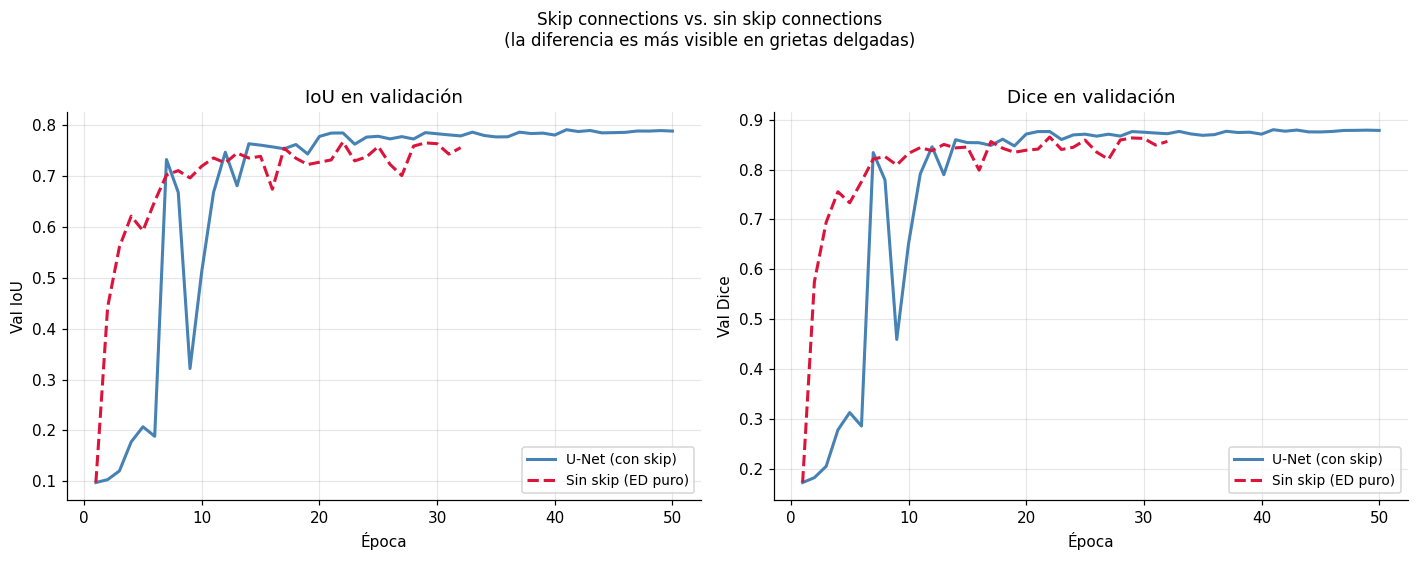

In [ ]:
def compilar_y_entrenar(modelo, ds_train, ds_val, epochs=50,
                          loss_fn=bce_dice_loss, lr=1e-3, nombre=""):
    """
    Compila y entrena un modelo de segmentación con callbacks estándar.
    """
    modelo.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss=loss_fn,
        metrics=[
            keras.metrics.BinaryAccuracy(name='acc'),
            DiceCoefficient(name='dice'),
            IoUMetric(name='iou')
        ]
    )

    cb = [
        EarlyStopping(monitor='val_iou', patience=10, mode='max',
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_iou', factor=0.5, patience=5,
                          mode='max', min_lr=1e-6, verbose=0),
        ModelCheckpoint(f'{nombre}_best.weights.h5', monitor='val_iou',
                        mode='max', save_best_only=True,
                        save_weights_only=True, verbose=0),
    ]

    t0 = time.time()
    hist = modelo.fit(
        ds_train, validation_data=ds_val,
        epochs=epochs, callbacks=cb, verbose=1
    )
    elapsed = time.time() - t0
    return hist, elapsed


# Entrenar ambas variantes (ejecutar si hay dataset disponible)
if len(img_paths) > 0:
    print("Entrenando U-Net con skip connections...")
    hist_full, t_full = compilar_y_entrenar(
        modelo_unet_full, ds_train, ds_val, nombre='unet_full')

    print("Entrenando Encoder-Decoder sin skip connections...")
    hist_nosup, t_nosup = compilar_y_entrenar(
        modelo_unet_nosup, ds_train, ds_val, nombre='unet_nosup')

    # Visualizar la diferencia
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for hist, nombre, color, ls in [
        (hist_full.history,  'U-Net (con skip)', 'steelblue', '-'),
        (hist_nosup.history, 'Sin skip (ED puro)', 'crimson', '--'),
    ]:
        ep = range(1, len(hist['val_iou']) + 1)
        axes[0].plot(ep, hist['val_iou'],  color=color, ls=ls, lw=2, label=nombre)
        axes[1].plot(ep, hist['val_dice'], color=color, ls=ls, lw=2, label=nombre)

    for ax, yl, tl in [
        (axes[0], 'Val IoU',  'IoU en validación'),
        (axes[1], 'Val Dice', 'Dice en validación'),
    ]:
        ax.set_xlabel('Época'); ax.set_ylabel(yl)
        ax.set_title(tl); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

    plt.suptitle("Skip connections vs. sin skip connections\n"
                 "(la diferencia es más visible en grietas delgadas)",
                 fontsize=11, y=1.01)
    plt.tight_layout()
    plt.show()



---



## 8. Experimento: capacidad de la red — ¿cuántos filtros necesitamos?


In [ ]:
configs_tamaño = {
    'Tiny  [8 base,  ~0.03M]':   {'filters_base': 4,  'depth': 3},
    'Small [16 base, ~0.5M]':   {'filters_base': 8, 'depth': 4},
    'Medium[32 base, ~2M]':     {'filters_base': 16, 'depth': 4},
    'Large [64 base, ~8M]':     {'filters_base': 32, 'depth': 4},
}

print("Configuraciones a comparar:\n")
print(f"  {'Config':<30}  {'Params':>10}  {'Filtros por nivel'}")
print("  " + "─"*65)
for nombre, cfg in configs_tamaño.items():
    m  = unet(filters_base=cfg['filters_base'], depth=cfg['depth'], nombre=nombre[:12])
    fb = cfg['filters_base']
    d  = cfg['depth']
    niveles = [fb * 2**i for i in range(d)] + [fb * 2**d]
    print(f"  {nombre:<30}  {m.count_params():>10,}  {niveles}")
    del m

Configuraciones a comparar:

  Config                              Params  Filtros por nivel
  ─────────────────────────────────────────────────────────────────
  Tiny  [8 base,  ~0.03M]             30,821  [4, 8, 16, 32]
  Small [16 base, ~0.5M]             487,881  [8, 16, 32, 64, 128]
  Medium[32 base, ~2M]             1,945,233  [16, 32, 64, 128, 256]
  Large [64 base, ~8M]             7,768,353  [32, 64, 128, 256, 512]


Para entrenamiento desde cero con `~500` imágenes:
  - Tiny/Small: riesgo de underfitting (grietas finas requieren alta resolución)
  - Medium:     balance ideal — capacidad suficiente sin overfitting
  - Large:      puede overfitear con pocos datos, necesita más regularización

In [ ]:
configs_tamaño = {
    'Tiny':   {'filters_base': 4,  'depth': 3},
    'Small':   {'filters_base': 8, 'depth': 4},
    'Medium':     {'filters_base': 16, 'depth': 4},
}


# Experimento de capacidad (entrenar todos si hay dataset)
resultados_tamaño = {}

if len(img_paths) > 0:
    for nombre_cfg, cfg in configs_tamaño.items():
        print(f"\nEntrenando {nombre_cfg}...")
        tf.random.set_seed(SEED)
        m = unet(
            filters_base=cfg['filters_base'],
            depth=cfg['depth'],
            use_bn=True, dropout=0.1, use_skip=True,
            nombre=nombre_cfg[:12].replace(' ', '_')
        )
        hist, elapsed = compilar_y_entrenar(
            m, ds_train, ds_val, epochs=60,
            nombre=nombre_cfg[:12].replace(' ', '_')
        )
        best_iou  = max(hist.history['val_iou'])
        best_dice = max(hist.history['val_dice'])
        n_params  = m.count_params()
        resultados_tamaño[nombre_cfg] = {
            'iou': best_iou, 'dice': best_dice,
            'params': n_params, 'tiempo': elapsed, 'history': hist.history
        }
        print(f"  → IoU={best_iou:.4f}  Dice={best_dice:.4f}  "
              f"t={elapsed:.0f}s  params={n_params:,}")

    # Tabla comparativa
    print("\n" + "═"*70)
    print("RESULTADOS — Comparación de tamaños de red")
    print("═"*70)
    print(f"\n  {'Config':<30}  {'Params':>10}  {'IoU':>8}  {'Dice':>8}  {'Tiempo':>8}")
    print("  " + "─"*68)
    for nombre_cfg, r in resultados_tamaño.items():
        print(f"  {nombre_cfg:<30}  {r['params']:>10,}  {r['iou']:>8.4f}  "
              f"{r['dice']:>8.4f}  {r['tiempo']:>6.0f}s")


Entrenando Tiny...
Epoch 1/60
37/37 ━━━━━━━━━━━━━━━━━━━━ 37s 457ms/step - acc: 0.7935 - dice: 0.4353 - iou: 0.3113 - loss: 0.6892 - val_acc: 0.9023 - val_dice: 0.0275 - val_iou: 0.0146 - val_loss: 0.6483 - learning_rate: 0.0010
Epoch 2/60
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - acc: 0.9157 - dice: 0.6170 - iou: 0.4923 - loss: 0.6105 - val_acc: 0.9031 - val_dice: 0.0373 - val_iou: 0.0195 - val_loss: 0.6221 - learning_rate: 0.0010
Epoch 3/60
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - acc: 0.9287 - dice: 0.6373 - iou: 0.5206 - loss: 0.5760 - val_acc: 0.9038 - val_dice: 0.0489 - val_iou: 0.0272 - val_loss: 0.5875 - learning_rate: 0.0010
Epoch 4/60
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - acc: 0.9331 - dice: 0.6467 - iou: 0.5337 - loss: 0.5366 - val_acc: 0.9105 - val_dice: 0.1669 - val_iou: 0.1060 - val_loss: 0.5607 - learning_rate: 0.0010
Epoch 5/60
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - acc: 0.9424 - dice: 0.7037 - iou: 0.5899 - loss: 0.4978 - val_acc: 0.9346 - val_dice: 0.5225 - va

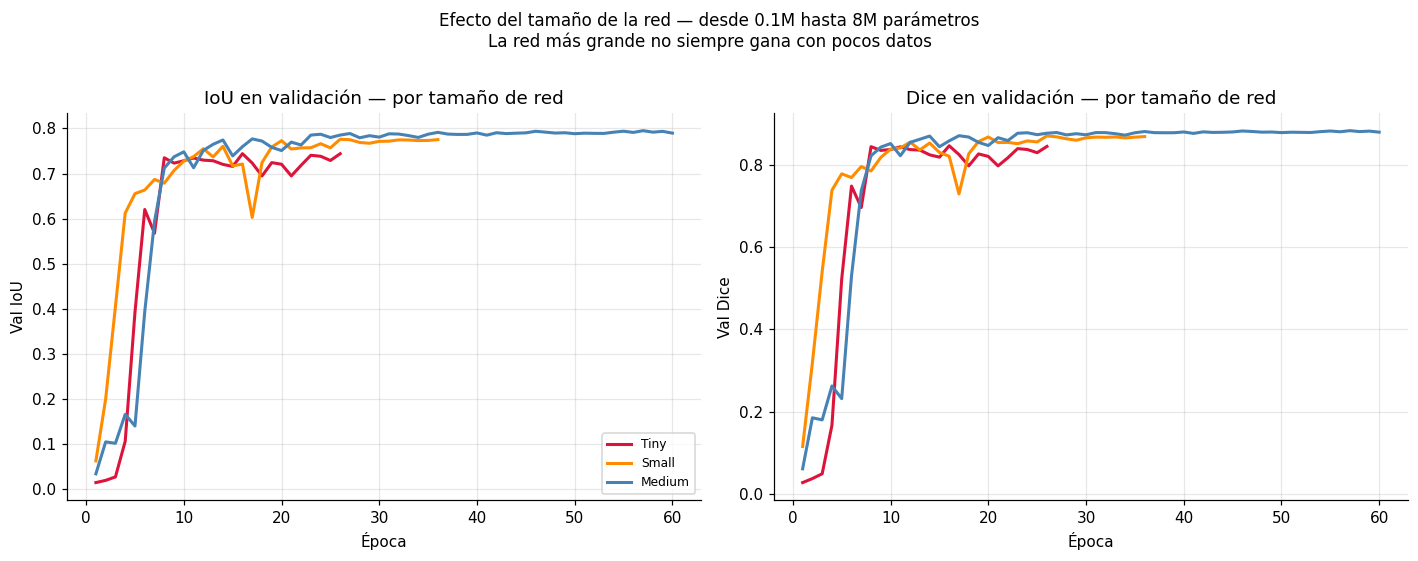

In [ ]:
# Visualización de curvas de entrenamiento por tamaño
if resultados_tamaño:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    colores = ['crimson', 'darkorange', 'steelblue', 'seagreen']

    for (nombre_cfg, r), color in zip(resultados_tamaño.items(), colores):
        ep = range(1, len(r['history']['val_iou']) + 1)
        axes[0].plot(ep, r['history']['val_iou'],  color=color, lw=2, label=nombre_cfg.split('[')[0].strip())
        axes[1].plot(ep, r['history']['val_dice'], color=color, lw=2)

    for ax, yl, tl in [
        (axes[0], 'Val IoU',  'IoU en validación — por tamaño de red'),
        (axes[1], 'Val Dice', 'Dice en validación — por tamaño de red'),
    ]:
        ax.set_xlabel('Época'); ax.set_ylabel(yl)
        ax.set_title(tl); ax.grid(True, alpha=0.3)
    axes[0].legend(fontsize=8)

    plt.suptitle("Efecto del tamaño de la red — desde 0.1M hasta 8M parámetros\n"
                 "La red más grande no siempre gana con pocos datos",
                 fontsize=11, y=1.01)
    plt.tight_layout()
    plt.show()


---



## 9. Experimento: función de pérdida


**IMPACTO DE LA FUNCIÓN DE PÉRDIDA EN SEGMENTACIÓN DE GRIETAS**

Desbalance típico: 5-15% de píxeles son grieta.

 - **Binary Cross-Entropy (BCE):**  
    Trata todos los píxeles por igual. Con 90% de fondo,
    minimizar la BCE puede converger a "predecir siempre fondo".  
    Dice=0, IoU=0, pero BCE baja. Engañoso.

 - **Dice Loss (1 - Dice):**  
    Optimiza directamente la métrica de evaluación.  
    Ignora el "fácil" fondo y se concentra en las regiones de grieta.  
    Puede ser inestable al inicio si las predicciones son muy malas.  

 - **BCE + Dice Loss (combinado):**  
    BCE da gradientes estables al inicio.  
    Dice Loss refina la detección de bordes en clases desbalanceadas.  
    Es el estándar más usado en la literatura de segmentación médica.  

 - **Focal Loss:**  
    Añade peso dinámico: píxeles difíciles de clasificar reciben
    mayor peso en el gradiente. Muy efectivo cuando la mayoría
    de los píxeles son "trivialmente" fondo.  
    Hyperparámetros: γ (focus) y α (class balance).  

  Entrenando con BCE_pura...
Epoch 1/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 47s 517ms/step - acc: 0.4990 - dice: 0.2839 - iou: 0.1848 - loss: 0.7487 - val_acc: 0.1002 - val_dice: 0.1549 - val_iou: 0.0858 - val_loss: 15.2785 - learning_rate: 0.0010
Epoch 2/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - acc: 0.8507 - dice: 0.5337 - iou: 0.4026 - loss: 0.5956 - val_acc: 0.7980 - val_dice: 0.1446 - val_iou: 0.0807 - val_loss: 0.6735 - learning_rate: 0.0010
Epoch 3/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - acc: 0.9262 - dice: 0.6153 - iou: 0.4871 - loss: 0.5335 - val_acc: 0.9039 - val_dice: 0.1523 - val_iou: 0.0937 - val_loss: 0.5666 - learning_rate: 0.0010
Epoch 4/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - acc: 0.9353 - dice: 0.6365 - iou: 0.5166 - loss: 0.4903 - val_acc: 0.9125 - val_dice: 0.1925 - val_iou: 0.1259 - val_loss: 0.5012 - learning_rate: 0.0010
Epoch 5/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step - acc: 0.9459 - dice: 0.6651 - iou: 0.5476 - loss: 0.4513 - val_acc: 0.9267 - val_dice: 0

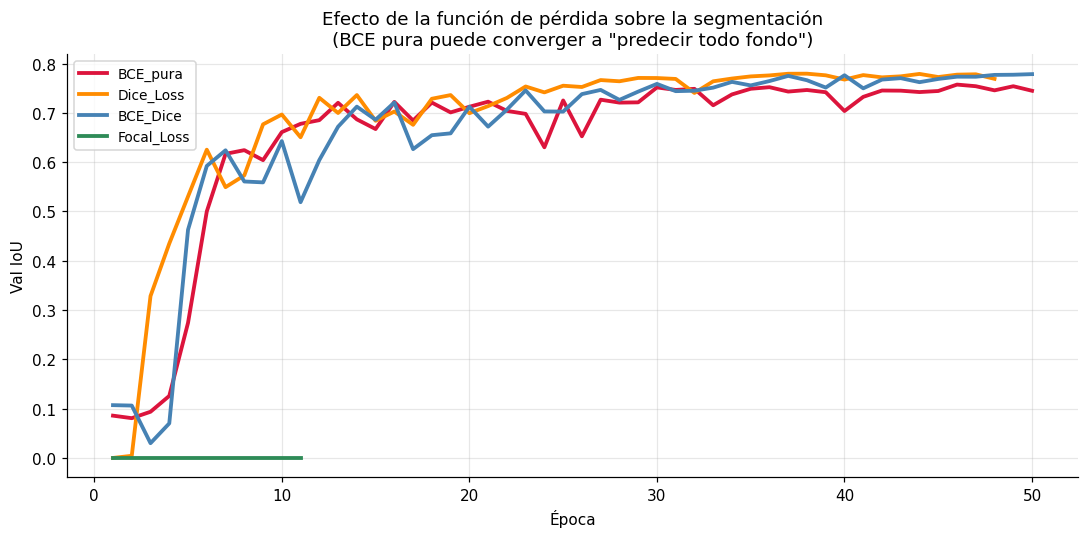

In [ ]:
if len(img_paths) > 0:
    resultados_loss = {}
    losses_a_probar = {
        'BCE_pura':     keras.losses.binary_crossentropy,
        'Dice_Loss':    dice_loss,
        'BCE_Dice':   bce_dice_loss,
        'Focal_Loss':   focal_loss,
    }

    for nombre_loss, loss_fn in losses_a_probar.items():
        print(f"  Entrenando con {nombre_loss}...")
        tf.random.set_seed(SEED)
        m = unet(filters_base=4, depth=4, use_bn=True, dropout=0.1,
                  nombre=f'unet_{nombre_loss[:4]}')
        hist, _ = compilar_y_entrenar(m, ds_train, ds_val, epochs=50,
                                       loss_fn=loss_fn,
                                       nombre=f'loss_{nombre_loss[:4]}')
        resultados_loss[nombre_loss] = {
            'iou': max(hist.history['val_iou']),
            'dice': max(hist.history['val_dice']),
            'history': hist.history
        }
        print(f"    IoU={resultados_loss[nombre_loss]['iou']:.4f}  "
              f"Dice={resultados_loss[nombre_loss]['dice']:.4f}")

    # Visualizar
    fig, ax = plt.subplots(figsize=(10, 5))
    colores = ['crimson', 'darkorange', 'steelblue', 'seagreen']
    for (nombre, r), c in zip(resultados_loss.items(), colores):
        ep = range(1, len(r['history']['val_iou']) + 1)
        ax.plot(ep, r['history']['val_iou'], color=c, lw=2.5, label=nombre)
    ax.set_xlabel('Época'); ax.set_ylabel('Val IoU')
    ax.set_title('Efecto de la función de pérdida sobre la segmentación\n'
                 '(BCE pura puede converger a "predecir todo fondo")')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


---



## 10. Modelo final — entrenamiento completo con mejores hiperparámetros


In [ ]:
# ═══════════════════════════════════════════════════════════════
# MODELO FINAL — combinar hallazgos de los experimentos
# ═══════════════════════════════════════════════════════════════
# · Arquitectura: U-Net con skip connections (demostrado superior)
# · Capacidad: filters_base=8, depth=4 (~2M params, balance ideal)
# · Loss: BCE + Dice (robusto al desbalance, estable)
# · Regularización: BatchNorm + SpatialDropout(0.1)
# · Augmentación: flip, rotación, brillo/contraste (sin color porque grayscale)
# ═══════════════════════════════════════════════════════════════

tf.random.set_seed(SEED)
modelo_final = unet(
    input_shape=(IMG_SIZE, IMG_SIZE, N_CHANNELS),
    filters_base=8,
    depth=4,
    use_bn=True,
    dropout=0.1,
    use_skip=True,
    n_convs_per_block=2,
    nombre='unet_final'
)

modelo_final.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=bce_dice_loss,
    metrics=[
        keras.metrics.BinaryAccuracy(name='acc'),
        DiceCoefficient(name='dice'),
        IoUMetric(name='iou'),
    ]
)

print("Modelo final:")
modelo_final.summary()

cb_final = [
    EarlyStopping(monitor='val_iou', mode='max', patience=15,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_iou', mode='max', factor=0.5,
                      patience=7, min_lr=1e-7, verbose=1),
    ModelCheckpoint('unet_final_best.keras', monitor='val_iou', mode='max',
                    save_best_only=True, verbose=0),
]

if len(img_paths) > 0:
    print("\nEntrenando modelo final (máx. 100 épocas)...")
    t0 = time.time()
    history_final = modelo_final.fit(
        ds_train, validation_data=ds_val,
        epochs=100, callbacks=cb_final, verbose=1
    )
    t_total = time.time() - t0
    print(f"\nEntrenamiento completado: {t_total:.0f}s")


Modelo final:


Model: "unet_final"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 256, 256,  │          0 │ -                 │
│                     │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc0_conv0 (Conv2D) │ (None, 256, 256,  │         72 │ input[0][0]       │
│                     │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc0_bn0            │ (None, 256, 256,  │         32 │ enc0_conv0[0][0]  │
│ (BatchNormalizatio… │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc0_relu0          │ (None, 256, 256,  │          0 │ enc0_bn0[0][0]    │
│ (Activation)        │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc0_conv1 (Conv2D) │ (None, 256, 256,  │        576 │ enc0_relu0[0][0]  │
│                     │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc0_bn1            │ (None, 256, 256,  │         32 │ enc0_conv1[0][0]  │
│ (BatchNormalizatio… │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc0_relu1          │ (None, 256, 256,  │          0 │ enc0_bn1[0][0]    │
│ (Activation)        │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc0_drop           │ (None, 256, 256,  │          0 │ enc0_relu1[0][0]  │
│ (SpatialDropout2D)  │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool0               │ (None, 128, 128,  │          0 │ enc0_drop[0][0]   │
│ (MaxPooling2D)      │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_conv0 (Conv2D) │ (None, 128, 128,  │      1,152 │ pool0[0][0]       │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_bn0            │ (None, 128, 128,  │         64 │ enc1_conv0[0][0]  │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_relu0          │ (None, 128, 128,  │          0 │ enc1_bn0[0][0]    │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_conv1 (Conv2D) │ (None, 128, 128,  │      2,304 │ enc1_relu0[0][0]  │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_bn1            │ (None, 128, 128,  │         64 │ enc1_conv1[0][0]  │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_relu1          │ (None, 128, 128,  │          0 │ enc1_bn1[0][0]    │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_drop           │ (None, 128, 128,  │          0 │ enc1_relu1[0][0]  │
│ (SpatialDropout2D)  │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 64, 64,    │          0 │ enc1_drop[0][0] 

 Total params: 487,881 (1.86 MB)

 Trainable params: 486,409 (1.86 MB)

 Non-trainable params: 1,472 (5.75 KB)


Entrenando modelo final (máx. 100 épocas)...
Epoch 1/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 44s 556ms/step - acc: 0.7737 - dice: 0.4970 - iou: 0.3552 - loss: 0.6656 - val_acc: 0.1615 - val_dice: 0.1438 - val_iou: 0.0787 - val_loss: 1.0481 - learning_rate: 0.0010
Epoch 2/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 77ms/step - acc: 0.9309 - dice: 0.7294 - iou: 0.5984 - loss: 0.5858 - val_acc: 0.4908 - val_dice: 0.1722 - val_iou: 0.1005 - val_loss: 0.7951 - learning_rate: 0.0010
Epoch 3/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 5s 78ms/step - acc: 0.9505 - dice: 0.7766 - iou: 0.6532 - loss: 0.5444 - val_acc: 0.9021 - val_dice: 0.2714 - val_iou: 0.1797 - val_loss: 0.6181 - learning_rate: 0.0010
Epoch 4/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 88ms/step - acc: 0.9575 - dice: 0.7961 - iou: 0.6773 - loss: 0.5064 - val_acc: 0.9299 - val_dice: 0.5025 - val_iou: 0.3723 - val_loss: 0.5538 - learning_rate: 0.0010
Epoch 5/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 70ms/step - acc: 0.9585 - dice: 0.7987 - iou: 0.6778 - loss: 0.4755 - val_acc:

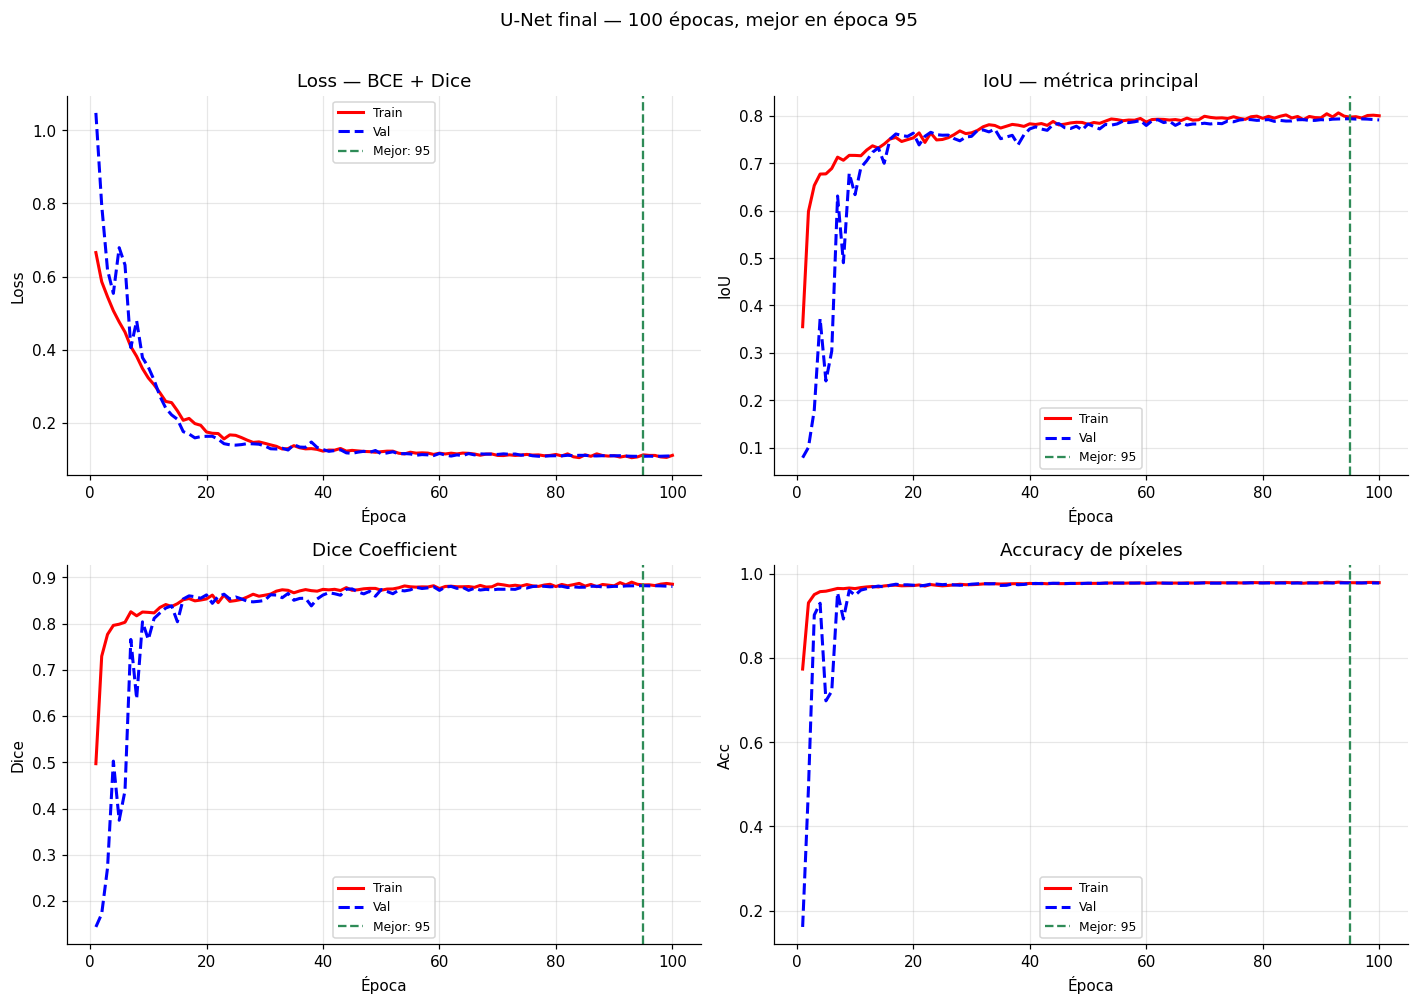

In [ ]:
if len(img_paths) > 0:
    # Curvas de entrenamiento finales
    fig, axes = plt.subplots(2, 2, figsize=(13, 9))
    hist = history_final.history
    ep_r = range(1, len(hist['loss']) + 1)
    best_ep = np.argmax(hist['val_iou']) + 1

    for ax, (tk, vk), yl, tl in [
        (axes[0,0], ('loss',  'val_loss'),  'Loss',  'Loss — BCE + Dice'),
        (axes[0,1], ('iou',   'val_iou'),   'IoU',   'IoU — métrica principal'),
        (axes[1,0], ('dice',  'val_dice'),  'Dice',  'Dice Coefficient'),
        (axes[1,1], ('acc',   'val_acc'),   'Acc',   'Accuracy de píxeles'),
    ]:
        ax.plot(ep_r, hist[tk], 'r-',  lw=2, label='Train')
        ax.plot(ep_r, hist[vk], 'b--', lw=2, label='Val')
        ax.axvline(best_ep, color='seagreen', lw=1.5, linestyle='--',
                   label=f'Mejor: {best_ep}')
        ax.set_xlabel('Época'); ax.set_ylabel(yl)
        ax.set_title(tl); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    plt.suptitle(f"U-Net final — {len(hist['loss'])} épocas, mejor en época {best_ep}",
                 fontsize=12, y=1.01)
    plt.tight_layout()
    plt.show()


---



## 11. Evaluación y análisis de predicciones


In [ ]:
def evaluar_modelo(modelo, ds_test, umbral=MASK_THR):
    """Evaluación completa sobre el conjunto de test."""
    todas_iou, todos_dice, todos_acc = [], [], []
    imagenes, masks_true, masks_pred = [], [], []

    for batch_imgs, batch_masks in ds_test:
        preds = modelo.predict(batch_imgs, verbose=0)
        preds_bin = (preds > umbral).astype(np.float32)

        for i in range(len(batch_imgs)):
            img   = batch_imgs[i].numpy()
            m_t   = batch_masks[i].numpy().flatten().astype(int)
            m_p   = preds_bin[i].flatten().astype(int)

            # IoU
            inter = (m_t & m_p).sum()
            union = (m_t | m_p).sum()
            iou   = inter / union if union > 0 else 1.0

            # Dice
            dice  = (2*inter) / (m_t.sum() + m_p.sum() + 1e-6)

            # Accuracy
            acc   = (m_t == m_p).mean()

            todas_iou.append(iou)
            todos_dice.append(dice)
            todos_acc.append(acc)
            imagenes.append(img)
            masks_true.append(batch_masks[i].numpy())
            masks_pred.append(preds[i])

    return {
        'iou_mean': np.mean(todas_iou),
        'dice_mean': np.mean(todos_dice),
        'acc_mean': np.mean(todos_acc),
        'iou_per_img': todas_iou,
        'imagenes': imagenes,
        'masks_true': masks_true,
        'masks_pred': masks_pred,
    }


if len(img_paths) > 0:
    eval_results = evaluar_modelo(modelo_final, ds_test)

    print("═"*55)
    print("RESULTADOS FINALES — Test set")
    print("═"*55)
    print(f"  IoU medio:             {eval_results['iou_mean']:.4f}")
    print(f"  Dice medio:            {eval_results['dice_mean']:.4f}")
    print(f"  Accuracy píxeles:      {eval_results['acc_mean']:.4f}")
    print()
    print(f"  IoU P10 (peor 10%):    {np.percentile(eval_results['iou_per_img'],10):.4f}")
    print(f"  IoU P50 (mediana):     {np.percentile(eval_results['iou_per_img'],50):.4f}")
    print(f"  IoU P90 (mejor 10%):   {np.percentile(eval_results['iou_per_img'],90):.4f}")
    print()
    buenos   = (np.array(eval_results['iou_per_img']) > 0.7).sum()
    aceptables = (np.array(eval_results['iou_per_img']) > 0.5).sum()
    print(f"  Imágenes con IoU > 0.7: {buenos}/{len(eval_results['iou_per_img'])} ({buenos/len(eval_results['iou_per_img'])*100:.1f}%)")
    print(f"  Imágenes con IoU > 0.5: {aceptables}/{len(eval_results['iou_per_img'])} ({aceptables/len(eval_results['iou_per_img'])*100:.1f}%)")

═══════════════════════════════════════════════════════
RESULTADOS FINALES — Test set
═══════════════════════════════════════════════════════
  IoU medio:             0.7811
  Dice medio:            0.8690
  Accuracy píxeles:      0.9754

  IoU P10 (peor 10%):    0.6306
  IoU P50 (mediana):     0.8176
  IoU P90 (mejor 10%):   0.9002

  Imágenes con IoU > 0.7: 50/62 (80.6%)
  Imágenes con IoU > 0.5: 58/62 (93.5%)


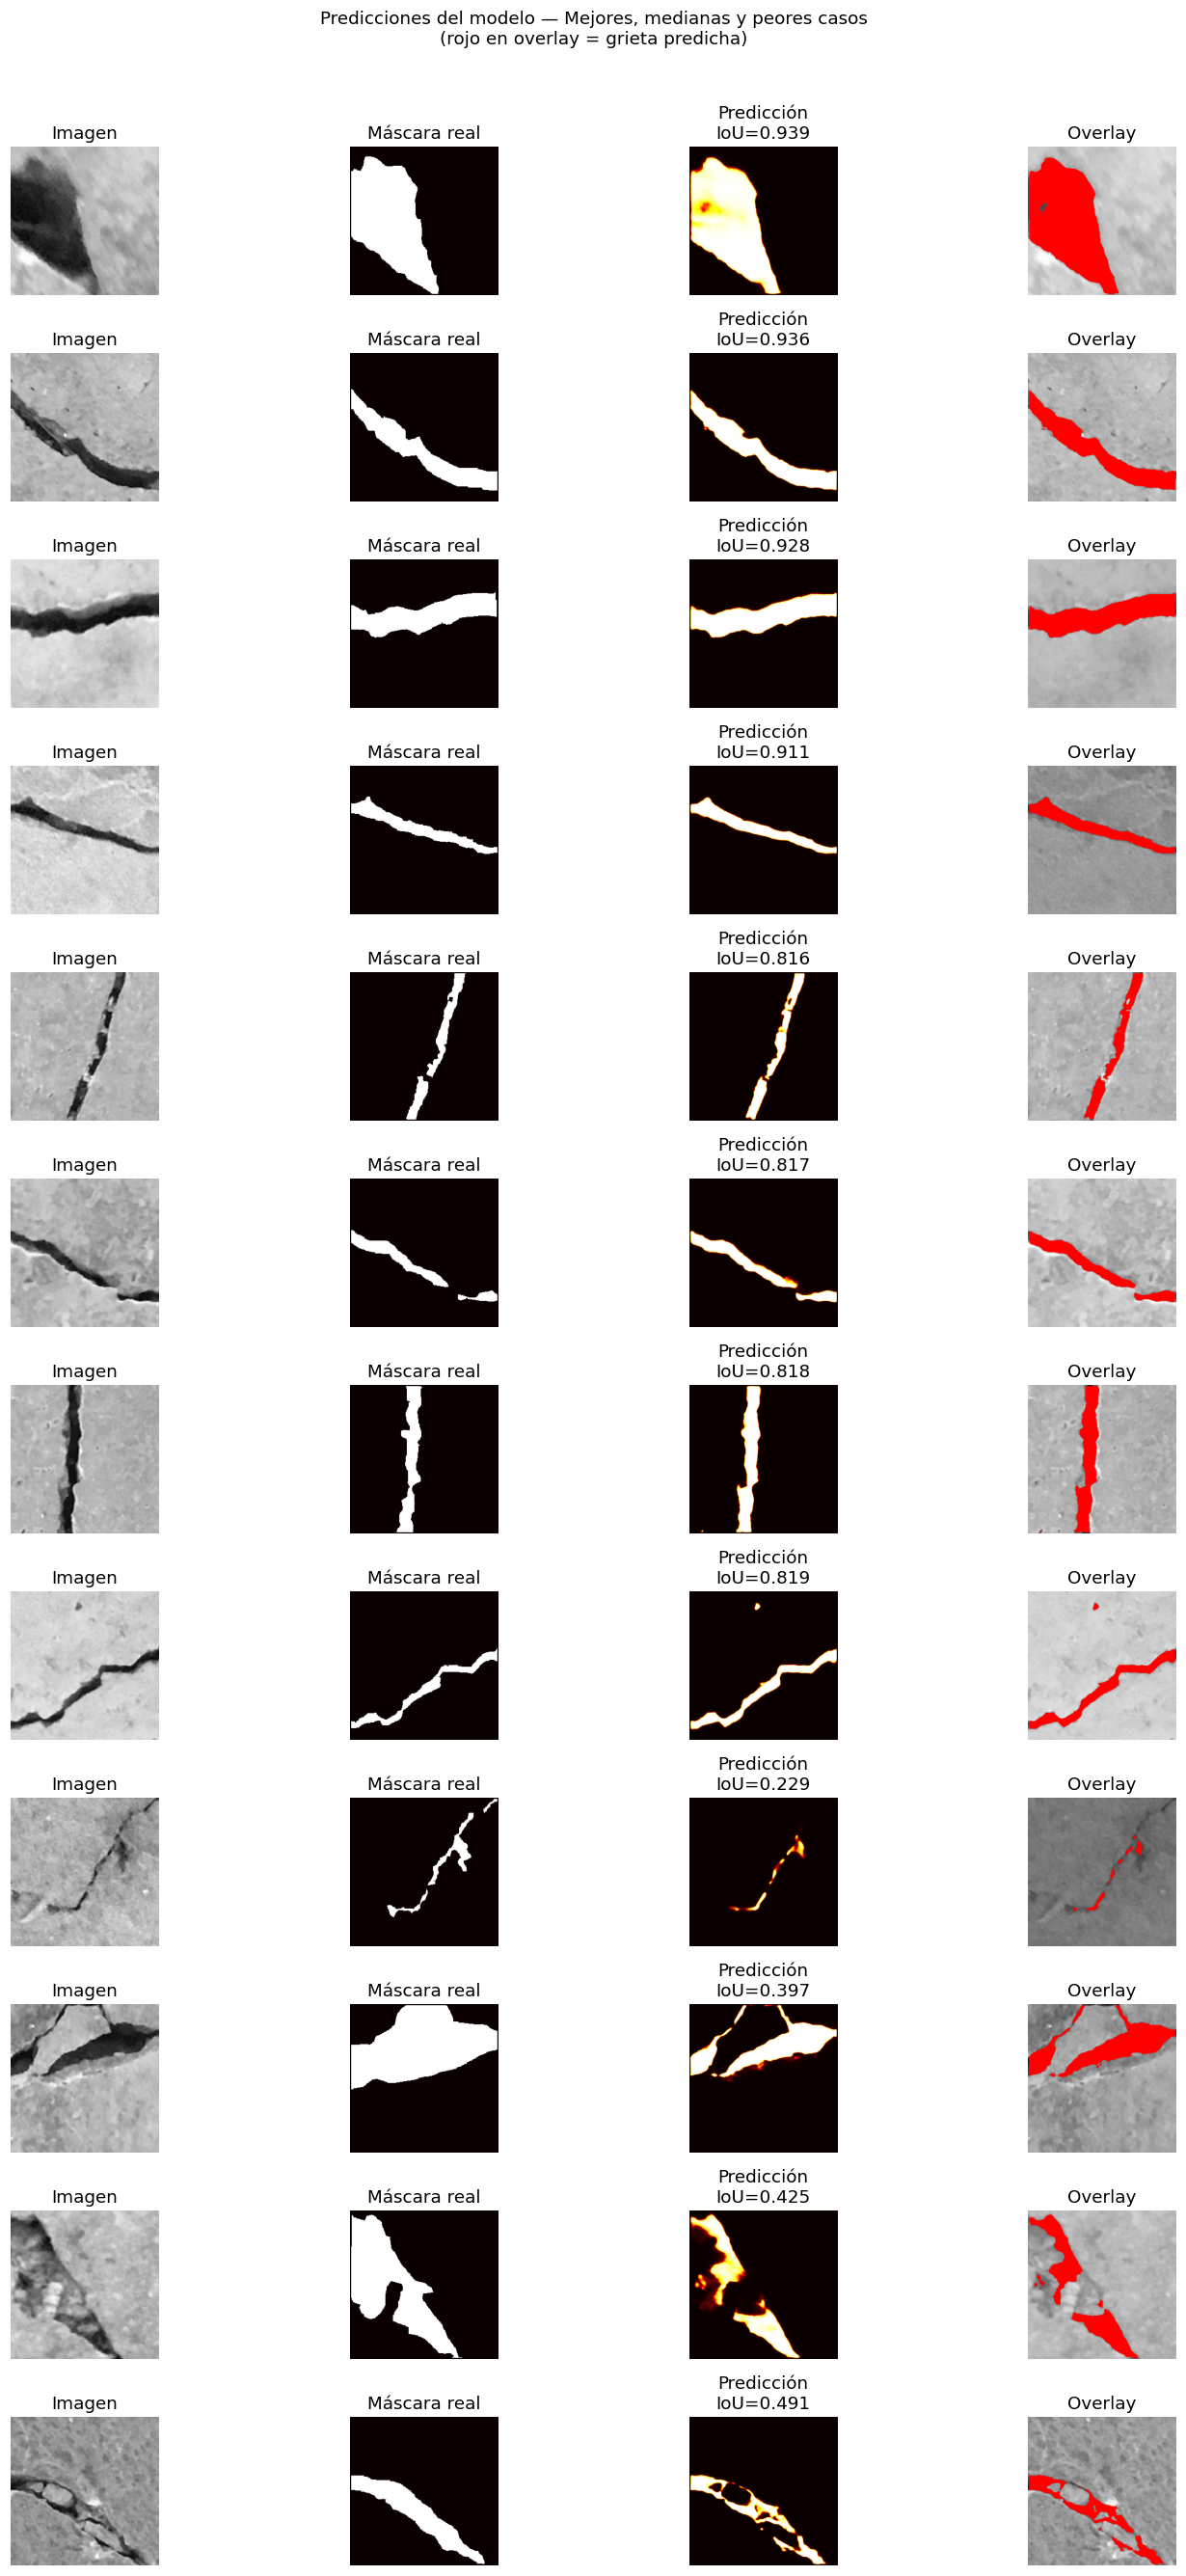

In [ ]:
if len(img_paths) > 0:
    # Visualizar predicciones
    ious     = eval_results['iou_per_img']
    n_imgs   = len(ious)
    idx_best = np.argsort(ious)[-4:][::-1]
    idx_med  = np.argsort(ious)[n_imgs//2 - 2: n_imgs//2 + 2]
    idx_worst= np.argsort(ious)[:4]

    fig, axes = plt.subplots(12, 4, figsize=(14, 24))

    for row_offset, (indices, grupo) in enumerate([
        (idx_best,  'MEJORES (IoU alto)'),
        (idx_med,   'MEDIANAS (IoU medio)'),
        (idx_worst, 'PEORES (IoU bajo)'),
    ]):
        for col, idx in enumerate(indices):
            row = row_offset * 4 + col // 4 * 4

        for subcol, idx in enumerate(indices[:4]):
            r = row_offset * 4
            img  = eval_results['imagenes'][idx][:, :, 0]
            mt   = eval_results['masks_true'][idx][:, :, 0]
            mp   = eval_results['masks_pred'][idx][:, :, 0]
            iou  = ious[idx]

            # Overlay: imagen + máscara predicha superpuesta
            overlay = np.stack([img, img, img], axis=-1)
            pred_bin = (mp > MASK_THR)
            overlay[pred_bin, 0] = 1.0   # rojo donde hay grieta predicha
            overlay[pred_bin, 1] = 0.0
            overlay[pred_bin, 2] = 0.0

            axes[r + subcol, 0].imshow(img, cmap='gray'); axes[r + subcol, 0].set_title(f"Imagen")
            axes[r + subcol, 1].imshow(mt, cmap='hot', vmin=0, vmax=1); axes[r + subcol, 1].set_title("Máscara real")
            axes[r + subcol, 2].imshow(mp, cmap='hot', vmin=0, vmax=1); axes[r + subcol, 2].set_title(f"Predicción\nIoU={iou:.3f}")
            axes[r + subcol, 3].imshow(overlay); axes[r + subcol, 3].set_title("Overlay")
            for ax in axes[r + subcol]: ax.axis('off')

        # Añadir etiqueta de grupo
        axes[row_offset*4, 0].set_ylabel(grupo, fontsize=9, rotation=0,
                                           labelpad=60, va='center')

    plt.suptitle("Predicciones del modelo — Mejores, medianas y peores casos\n"
                 "(rojo en overlay = grieta predicha)",
                 fontsize=12, y=1.01)
    plt.tight_layout()
    plt.show()


---



## 12. Análisis de umbrales y despliegue en campo



OPTIMIZACIÓN DEL UMBRAL DE DECISIÓN

El modelo produce probabilidades por píxel (0-1).
La decisión binaria requiere un umbral. Con grietas:
  · Umbral bajo (0.2-0.3): más sensible, detecta grietas dudosas,
    pero puede marcar textura rugosa como grieta (FP)
  · Umbral alto (0.7-0.8): muy conservador, solo grietas claras,
    puede perder grietas finas en inicio (FN)
  · Umbral estándar (0.5): punto de partida, no siempre el óptimo

Para inspección estructural: preferimos recall alto (no perder grietas).



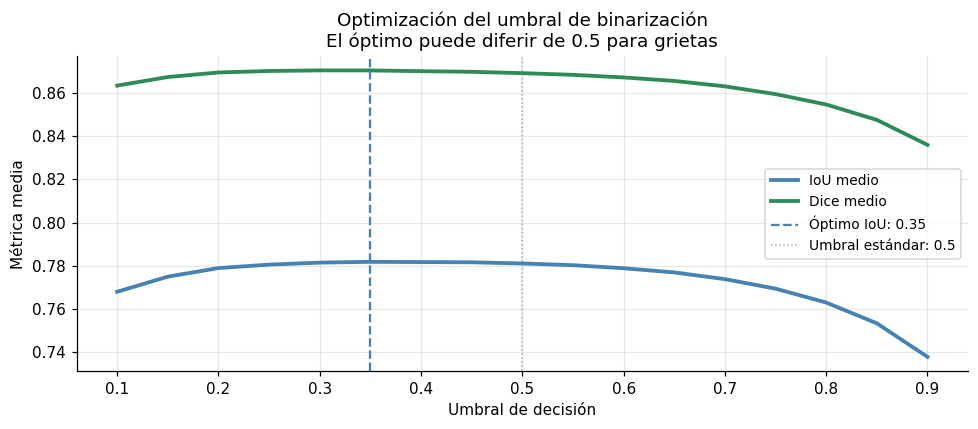

Umbral óptimo por IoU:  0.35  (IoU=0.7818)
Umbral óptimo por Dice: 0.30  (Dice=0.8703)


In [ ]:
if len(img_paths) > 0:
    print("""
OPTIMIZACIÓN DEL UMBRAL DE DECISIÓN

El modelo produce probabilidades por píxel (0-1).
La decisión binaria requiere un umbral. Con grietas:
  · Umbral bajo (0.2-0.3): más sensible, detecta grietas dudosas,
    pero puede marcar textura rugosa como grieta (FP)
  · Umbral alto (0.7-0.8): muy conservador, solo grietas claras,
    puede perder grietas finas en inicio (FN)
  · Umbral estándar (0.5): punto de partida, no siempre el óptimo

Para inspección estructural: preferimos recall alto (no perder grietas).
""")

    # Sweep de umbrales sobre el test set
    ious_por_umbral  = {}
    dices_por_umbral = {}
    umbrales_sweep   = np.arange(0.1, 0.95, 0.05)

    for u in umbrales_sweep:
        iou_vals, dice_vals = [], []
        for mt, mp in zip(eval_results['masks_true'], eval_results['masks_pred']):
            m_t = mt.flatten().astype(int)
            m_p = (mp.flatten() > u).astype(int)
            inter = (m_t & m_p).sum()
            union = (m_t | m_p).sum()
            iou_vals.append(inter / union if union > 0 else 1.0)
            dice_vals.append(2*inter / (m_t.sum() + m_p.sum() + 1e-6))
        ious_por_umbral[u]  = np.mean(iou_vals)
        dices_por_umbral[u] = np.mean(dice_vals)

    umbral_opt_iou  = max(ious_por_umbral,  key=ious_por_umbral.get)
    umbral_opt_dice = max(dices_por_umbral, key=dices_por_umbral.get)

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(list(ious_por_umbral.keys()),  list(ious_por_umbral.values()),
             'steelblue', lw=2.5, label='IoU medio')
    ax.plot(list(dices_por_umbral.keys()), list(dices_por_umbral.values()),
             'seagreen', lw=2.5, label='Dice medio')
    ax.axvline(umbral_opt_iou, color='steelblue', lw=1.5, linestyle='--',
               label=f'Óptimo IoU: {umbral_opt_iou:.2f}')
    ax.axvline(0.5, color='gray', lw=1, linestyle=':', alpha=0.6, label='Umbral estándar: 0.5')
    ax.set_xlabel("Umbral de decisión")
    ax.set_ylabel("Métrica media")
    ax.set_title("Optimización del umbral de binarización\n"
                 "El óptimo puede diferir de 0.5 para grietas")
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"Umbral óptimo por IoU:  {umbral_opt_iou:.2f}  (IoU={ious_por_umbral[umbral_opt_iou]:.4f})")
    print(f"Umbral óptimo por Dice: {umbral_opt_dice:.2f}  (Dice={dices_por_umbral[umbral_opt_dice]:.4f})")


## 13. Cuantificación de daño y viabilidad del sistema


In [ ]:
def calcular_porcentaje_dano(prediccion: np.ndarray,
                               umbral: float = MASK_THR,
                               pixel_size_cm: float = 0.1) -> dict:
    """
    Dado el mapa de predicciones de un modelo, calcula el porcentaje
    de área afectada y la longitud estimada de grietas.

    Parámetros
    ----------
    prediccion     : array (H, W, 1) con probabilidades [0,1]
    umbral         : umbral de binarización
    pixel_size_cm  : tamaño real de cada píxel en cm (depende de la distancia de captura)

    Para uso en campo: calibrar pixel_size_cm con una referencia de escala conocida.
    """
    mask_bin = (prediccion[:, :, 0] > umbral).astype(np.uint8)

    # Área afectada
    pct_afectado = mask_bin.mean() * 100
    n_pixels_grieta = mask_bin.sum()
    area_cm2 = n_pixels_grieta * (pixel_size_cm ** 2)

    # Longitud de grieta (morfología esqueletal)
    skeleton = cv2.ximgproc.thinning(mask_bin * 255) if hasattr(cv2, 'ximgproc') else mask_bin
    longitud_px = skeleton.sum() if skeleton.max() > 1 else mask_bin.sum()
    longitud_cm = longitud_px * pixel_size_cm

    # Ancho promedio (área / longitud)
    ancho_promedio = (n_pixels_grieta / (longitud_px + 1e-6)) * pixel_size_cm

    return {
        'pct_afectado': pct_afectado,
        'area_cm2':     area_cm2,
        'longitud_cm':  longitud_cm,
        'ancho_mm':     ancho_promedio * 10,
        'severidad':    'grave' if pct_afectado > 10 else
                        ('moderada' if pct_afectado > 3 else 'leve')
    }


print("Función de cuantificación de daño disponible.")
print("Uso:")
print("  resultado = calcular_porcentaje_dano(prediccion, pixel_size_cm=0.05)")
print("  → pct_afectado, area_cm2, longitud_cm, ancho_mm, severidad")
print()
print("Para uso en campo: la escala depende de la distancia de captura.")
print("Calibrar midiendo una referencia de tamaño conocido en la imagen.")


Función de cuantificación de daño disponible.
Uso:
  resultado = calcular_porcentaje_dano(prediccion, pixel_size_cm=0.05)
  → pct_afectado, area_cm2, longitud_cm, ancho_mm, severidad

Para uso en campo: la escala depende de la distancia de captura.
Calibrar midiendo una referencia de tamaño conocido en la imagen.



---

*Fin de la Experiencia 4 — Laboratorio 2: Segmentación de Grietas con U-Net.*
